<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Weight initializations</h1>
<p>If we initialize the model with too little (or 0) weights, we risk vanishing gradients. If it is all 0, the model will learn nothing. If they are too large, we can have exploding gradients. There are two widespread algorithms for initializing weights: Xavier and Kaiming. In PyTorch Kaiming is the default, it produces uniform distribution scaled by 1/number of inputs.</p>
</div>

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [15]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(100, 100)

        self.fc1 = nn.Linear(50, 100)
        self.fc2 = nn.Linear(100, 200)
        self.fc3 = nn.Linear(200, 100)

        self.output = nn.Linear(100, 2)
    
    def forward(self, x):
        x = F.relu(self.input(x))
        for h in self.hidden:
            x = F.relu(h(x))
        return self.output(x)

In [16]:
model = Model()
print(model)

allweights = np.array([])
allbiases = np.array([])

for p in model.named_parameters():
    if 'bias' in p[0]:
        allbiases = np.concatenate((allbiases, p[1].data.numpy().flatten()), axis=0)
    elif 'weight' in p[0]:
        allweights = np.concatenate((allweights, p[1].data.numpy().flatten()), axis=0)

print(f'There are {len(allbiases)} bias terms.')
print(f'There are {len(allweights)} weight terms.')

Model(
  (input): Linear(in_features=100, out_features=100, bias=True)
  (fc1): Linear(in_features=50, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=200, bias=True)
  (fc3): Linear(in_features=200, out_features=100, bias=True)
  (output): Linear(in_features=100, out_features=2, bias=True)
)
There are 502 bias terms.
There are 55200 weight terms.


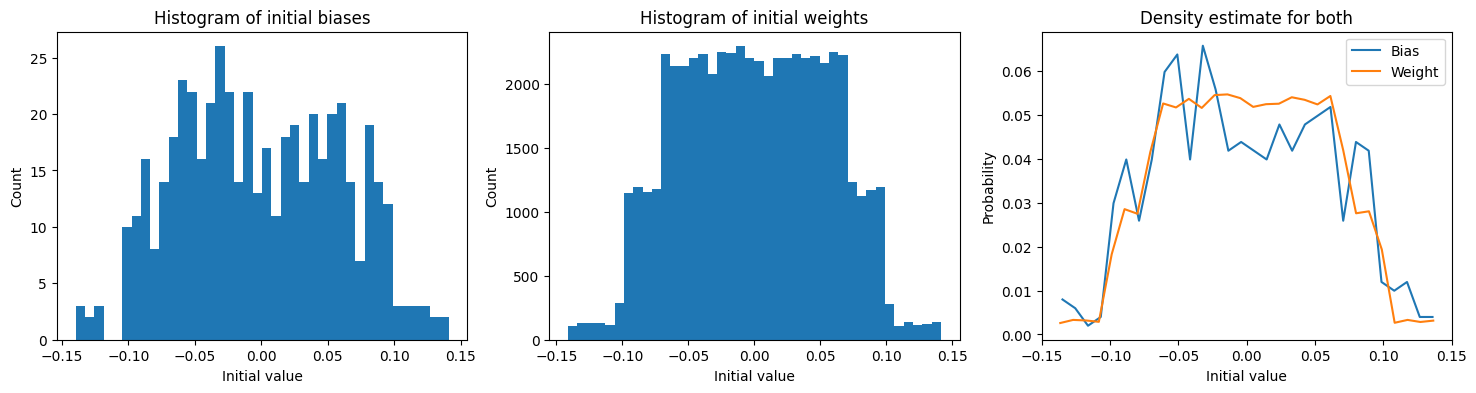

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18,4))

ax[0].hist(allbiases, 40)
ax[0].set_title('Histogram of initial biases')

ax[1].hist(allweights, 40)
ax[1].set_title('Histogram of initial weights')

yB,xB = np.histogram(allbiases, 30)
yW,xW = np.histogram(allweights, 30)

ax[2].plot((xB[1:]+xB[:-1])/2, yB/np.sum(yB), label='Bias')
ax[2].plot((xW[1:]+xW[:-1])/2, yW/np.sum(yW), label='Weight')
ax[2].set_title('Density estimate for both')
ax[2].legend()

for i in range(3):
    ax[i].set_xlabel('Initial value')
    ax[i].set_ylabel('Count')
ax[2].set_ylabel('Probability')

plt.show()

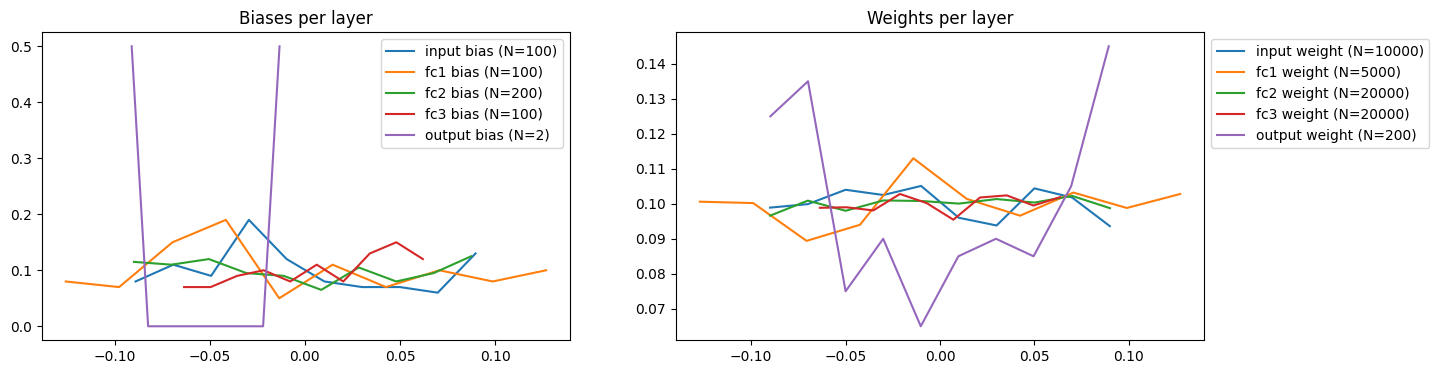

In [18]:
fig,ax = plt.subplots(1,2,figsize=(15,4))

for p in model.named_parameters():

  # get the data and compute their histogram
  thesedata = p[1].data.numpy().flatten()
  y,x = np.histogram(thesedata,10)

  # for the bias
  if 'bias' in p[0]:
    ax[0].plot((x[1:]+x[:-1])/2,y/np.sum(y),label='%s bias (N=%g)'%(p[0][:-5],len(thesedata)))

  # for the weights
  elif 'weight' in p[0]:
    ax[1].plot((x[1:]+x[:-1])/2,y/np.sum(y),label='%s weight (N=%g)'%(p[0][:-7],len(thesedata)))



ax[0].set_title('Biases per layer')
ax[0].legend()
ax[1].set_title('Weights per layer')
ax[1].legend(bbox_to_anchor=(1,1),loc='upper left')
plt.show()

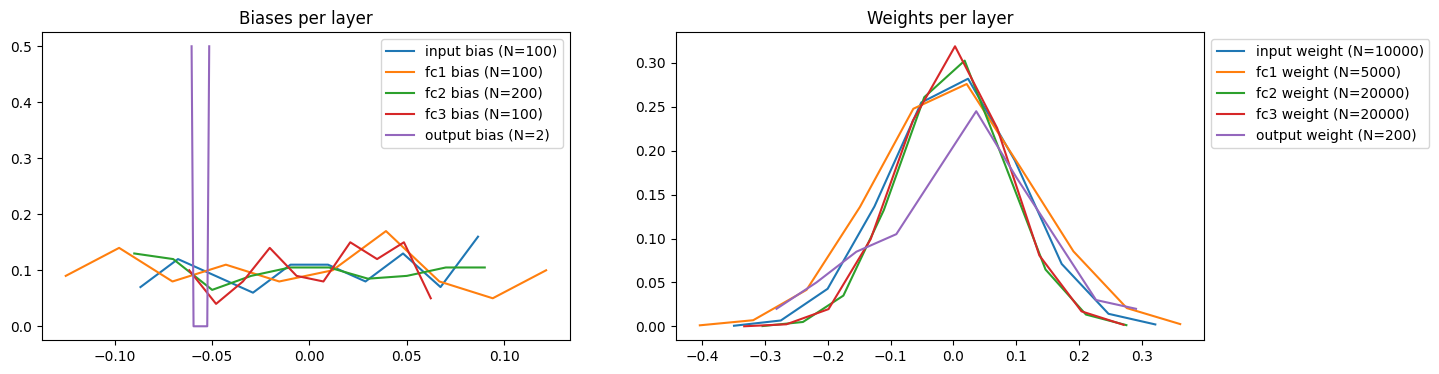

In [19]:
model = Model()

for p in model.named_parameters():
  if 'weight' in p[0]:
    nn.init.xavier_normal_(p[1].data)

fig,ax = plt.subplots(1,2,figsize=(15,4))

for p in model.named_parameters():

  # get the data and compute their histogram
  thesedata = p[1].data.numpy().flatten()
  y,x = np.histogram(thesedata,10)

  # for the bias
  if 'bias' in p[0]:
    ax[0].plot((x[1:]+x[:-1])/2,y/np.sum(y),label='%s bias (N=%g)'%(p[0][:-5],len(thesedata)))

  # for the weights
  elif 'weight' in p[0]:
    ax[1].plot((x[1:]+x[:-1])/2,y/np.sum(y),label='%s weight (N=%g)'%(p[0][:-7],len(thesedata)))



ax[0].set_title('Biases per layer')
ax[0].legend()
ax[1].set_title('Weights per layer')
ax[1].legend(bbox_to_anchor=(1,1),loc='upper left')
plt.show()